# Plotting the solution of the discrete model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Retrieve the data

In [2]:
data = np.fromfile('simulation_data_2d.bin', dtype=np.float64)
df = data.reshape(-1, 3, 202, 202)

### Using 'Imshow'

In [3]:
for t_idx in range(df.shape[0]):
    grid = df[t_idx, 0, 1:-1, 1:-1]

    fig, ax = plt.subplots()
    im = ax.imshow(grid, cmap='Greys', origin='lower', extent=[0, 1, 0, 1])
    ax.set_title(f"t={t_idx*0.1:0.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    filename = f"figures/frame_{t_idx:03d}.png"
    plt.savefig(filename)
    plt.close(fig)

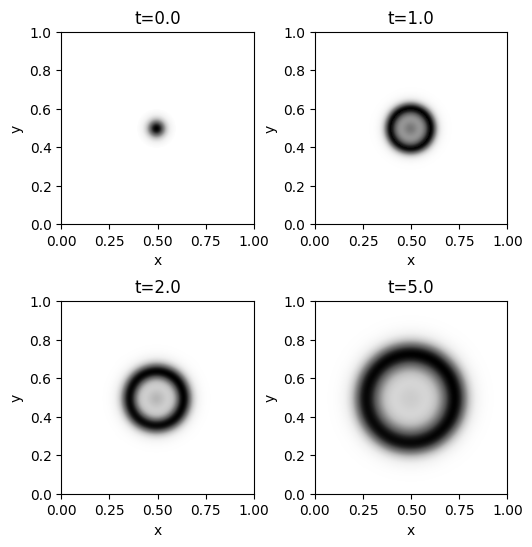

In [4]:
time_indices = [0, 10, 20, 50]
fig, ax = plt.subplots(2, 2, figsize=(6,6))

for i, t_idx in enumerate(time_indices):
    row = i // 2
    col = i % 2
    grid = df[t_idx, 0, 1:-1, 1:-1]
    ax[row, col].imshow(grid, cmap='Greys', origin='lower', extent=[0, 1, 0, 1])
    ax[row, col].set_title(f"t={t_idx*0.1:0.1f}")
    ax[row, col].set_xlabel("x")
    ax[row, col].set_ylabel("y")

plt.subplots_adjust(hspace=0.4)
plt.show()

### Creating a video

In [5]:
import imageio.v2 as imageio
import glob

images = sorted(glob.glob("figures/frame_*.png"))
frames = [imageio.imread(f) for f in images]

imageio.mimsave('animations/animation2d.mp4', frames, fps=30)